# Analisis Krisis Metabolik pada Sepsis

**Mata Kuliah:** IF3211 Komputasi Domain Khusus (Biologi Komputasional)  
**Topik:** Respirasi Sel & Produksi ATP — Deteksi Dini Hipoksia Jaringan via MLP + SHAP  
**Mahasiswa:** Peter Wongsoredjo — NIM `13523039`  
**Deadline:** 29 Mei 2026

Notebook ini merupakan pipeline end-to-end. Section saat ini hanya berisi **EDA** (sebelum drop kolom / imputasi). Section 2–5 (preprocessing, training MLP, evaluasi, SHAP) akan ditambahkan menyusul sesuai `CLAUDE.md`.

## Section 1: Exploratory Data Analysis (EDA)

Tujuan EDA ini adalah memahami struktur data **sebelum** melakukan `drop` kolom shortcut (`ICULOS`, `Hour`, `HospAdmTime`) maupun imputasi. Tiga subsection:
1. Analisis Sparsity (missing value per kolom)
2. Asosiasi Feature–Target (|Pearson r| terhadap `SepsisLabel`)
3. Class balance dari target

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", 60)

df = pd.read_csv("../data/Dataset.csv", index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (1552210, 43)


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


### 1.1 Missing Value (Sparsity) Analysis

In [2]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.to_frame("missing_pct").round(2)
print("Missing % per kolom (desc):")
print(missing_table.to_string())

focus = ["Lactate", "O2Sat", "pH", "PaCO2", "SaO2", "Resp"]
print("\nFocus clinical markers (missing %):")
print(missing_pct.loc[focus].round(2).to_string())

Missing % per kolom (desc):
                  missing_pct
Bilirubin_direct        99.81
Fibrinogen              99.34
TroponinI               99.05
Bilirubin_total         98.51
Alkalinephos            98.39
AST                     98.38
Lactate                 97.33
PTT                     97.06
SaO2                    96.55
EtCO2                   96.29
Phosphate               95.99
HCO3                    95.81
Chloride                95.46
BaseExcess              94.58
PaCO2                   94.44
Calcium                 94.12
Platelets               94.06
Creatinine              93.90
Magnesium               93.69
WBC                     93.59
BUN                     93.13
pH                      93.07
Hgb                     92.62
FiO2                    91.67
Hct                     91.15
Potassium               90.69
Glucose                 82.89
Temp                    66.16
Unit2                   39.43
Unit1                   39.43
DBP                     31.35
Resp        

### 1.2 Feature–Target Association (|Pearson r|)

NaN diisi sementara dengan median **hanya** untuk perhitungan korelasi (tidak dipersist).

Top 15 |Pearson r| vs SepsisLabel:
ICULOS             0.1338
Hour               0.1338
HR                 0.0472
Resp               0.0430
Temp               0.0280
Patient_ID         0.0279
HospAdmTime        0.0191
BUN                0.0189
MAP                0.0172
Calcium            0.0156
DBP                0.0145
Lactate            0.0132
SBP                0.0124
WBC                0.0122
Bilirubin_total    0.0119


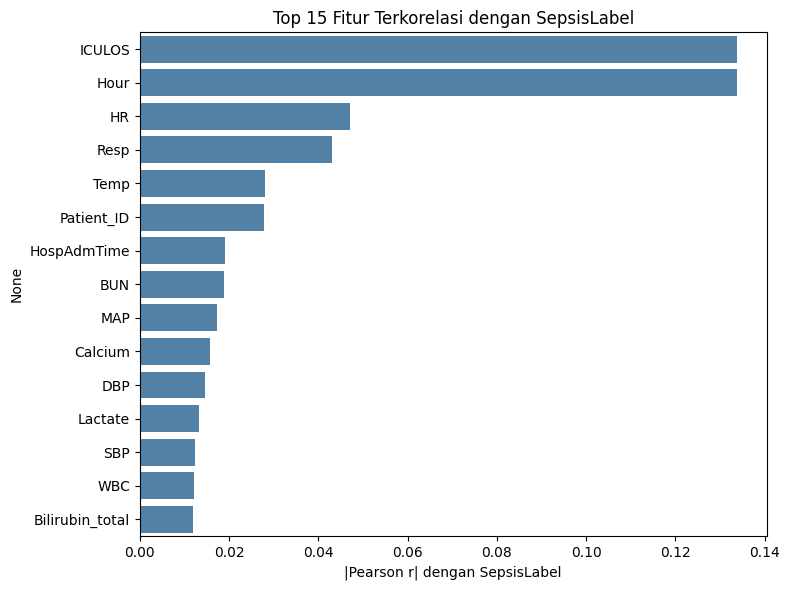

In [3]:
num = df.select_dtypes(include=[np.number]).copy()
num_filled = num.fillna(num.median(numeric_only=True))
corr = num_filled.corr(method="pearson")["SepsisLabel"].drop("SepsisLabel").abs()
top15 = corr.sort_values(ascending=False).head(15)
print("Top 15 |Pearson r| vs SepsisLabel:")
print(top15.round(4).to_string())

os.makedirs("../reports", exist_ok=True)
plt.figure(figsize=(8, 6))
sns.barplot(x=top15.values, y=top15.index, orient="h", color="steelblue")
plt.xlabel("|Pearson r| dengan SepsisLabel")
plt.title("Top 15 Fitur Terkorelasi dengan SepsisLabel")
plt.tight_layout()
plt.savefig("../reports/eda_feature_correlation.png", dpi=150)
plt.show()

### 1.3 Target Class Balance

In [4]:
counts = df["SepsisLabel"].value_counts().sort_index()
pcts = (df["SepsisLabel"].value_counts(normalize=True).sort_index() * 100).round(3)
summary = pd.DataFrame({"count": counts, "pct": pcts})
print(summary)
print(f"\nImbalance ratio (neg:pos) = {counts.loc[0] / counts.loc[1]:.1f} : 1")

               count     pct
SepsisLabel                 
0            1524294  98.202
1              27916   1.798

Imbalance ratio (neg:pos) = 54.6 : 1


### Catatan Interim (akan dipakai di Section 2 & 3)

- Marker biologis utama (`Lactate`, `O2Sat`, `pH`, `PaCO2`, `SaO2`) cenderung sparse → membenarkan strategi **`groupby(Patient_ID) → ffill → median`** di Section 2.
- Jika `ICULOS` / `Hour` / `HospAdmTime` muncul di Top-15 korelasi, ini adalah **shortcut administratif/temporal** yang harus di-drop sebelum training (sesuai guardrail anti-cheating di `CLAUDE.md`).
- Ketidakseimbangan kelas yang ekstrem → membenarkan **minority oversampling** pada training set di Section 3.

## Section 2: Balanced Resampling and Secondary EDA

Pipeline preprocessing terkontrol untuk mencegah model mengambil shortcut administratif (`ICULOS`, `Hour`, `HospAdmTime`, `Patient_ID`) dan memastikan marker biologis (`Lactate`, `O2Sat`, dst.) mendominasi sinyal.

Langkah:
1. **Imputasi per-pasien**: `groupby(Patient_ID).ffill()` lalu fill sisa NaN dengan median global.
2. **Downsampling kelas mayoritas**: rasio 1:2 (negatif:positif) dengan `random_state=42`.
3. **Secondary EDA**: hitung ulang |Pearson r| pada dataset balanced, plot Top-15 fitur.

### 2.1 Imputasi Timeline per-Pasien (ffill + median)

In [5]:
# Re-load fresh copy to keep Section 1 EDA frame intact
df_raw = pd.read_csv("../data/Dataset.csv", index_col=0)
df_raw = df_raw.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)
print("Raw shape:", df_raw.shape)
print("NaN total sebelum imputasi:", int(df_raw.isna().sum().sum()))

clinical_cols = [c for c in df_raw.columns if c not in ("Patient_ID", "SepsisLabel")]

df_imp = df_raw.copy()
df_imp[clinical_cols] = (
    df_imp.groupby("Patient_ID")[clinical_cols].ffill()
)

global_medians = df_imp[clinical_cols].median(numeric_only=True)
df_imp[clinical_cols] = df_imp[clinical_cols].fillna(global_medians)

print("NaN total setelah ffill + median:", int(df_imp.isna().sum().sum()))
df_imp.head()

Raw shape: (1552210, 43)
NaN total sebelum imputasi: 43512155


NaN total setelah ffill + median: 0


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,83.0,98.0,36.83,121.0,81.00,62.0,18.0,34.0,0.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,1,0,1
1,1,97.0,95.0,36.83,98.0,75.33,62.0,19.0,34.0,0.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,2,0,1
2,2,89.0,99.0,36.83,122.0,86.00,62.0,22.0,34.0,0.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,3,0,1
3,3,90.0,95.0,36.83,122.0,86.00,62.0,30.0,34.0,24.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,4,0,1
4,4,103.0,88.5,36.83,122.0,91.33,62.0,24.5,34.0,24.0,...,264.0,190.0,83.14,0,0.0,1.0,-0.03,5,0,1


### 2.2 Majority Class Downsampling (rasio 1:2)

In [6]:
pos = df_imp[df_imp["SepsisLabel"] == 1]
neg = df_imp[df_imp["SepsisLabel"] == 0]
print(f"Positif (Sepsis=1): {len(pos):,} rows")
print(f"Negatif (Sepsis=0): {len(neg):,} rows")

n_neg_sample = 2 * len(pos)
neg_sampled = neg.sample(n=n_neg_sample, random_state=42)

df_balanced = (
    pd.concat([pos, neg_sampled], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print("Distribusi kelas (balanced):")
print(df_balanced["SepsisLabel"].value_counts().to_string())
print(f"\nRatio neg:pos = {(df_balanced['SepsisLabel']==0).sum() / (df_balanced['SepsisLabel']==1).sum():.2f} : 1")

Positif (Sepsis=1): 27,916 rows
Negatif (Sepsis=0): 1,524,294 rows

Balanced dataset shape: (83748, 43)
Distribusi kelas (balanced):
SepsisLabel
0    55832
1    27916

Ratio neg:pos = 2.00 : 1


### 2.3 Secondary EDA: Top 15 |Pearson r| pada Dataset Balanced

Top 15 |Pearson r| vs SepsisLabel (Balanced Dataset):
HR                  0.1664
Temp                0.1559
BUN                 0.1348
Resp                0.1346
WBC                 0.1028
Fibrinogen          0.0845
Hgb                 0.0806
Hct                 0.0737
Calcium             0.0730
Bilirubin_total     0.0722
MAP                 0.0682
Creatinine          0.0610
PTT                 0.0580
Bilirubin_direct    0.0549
DBP                 0.0545


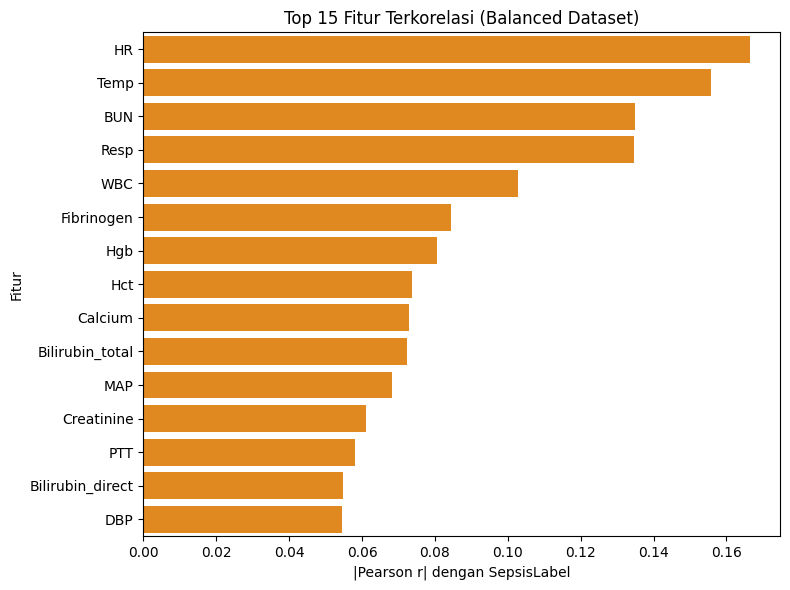

In [7]:
admin_cols = ["ICULOS", "Hour", "HospAdmTime", "Patient_ID"]
df_eda = df_balanced.drop(columns=admin_cols)

num_b = df_eda.select_dtypes(include=[np.number])
corr_b = num_b.corr(method="pearson")["SepsisLabel"].drop("SepsisLabel").abs()
top15_b = corr_b.sort_values(ascending=False).head(15)

print("Top 15 |Pearson r| vs SepsisLabel (Balanced Dataset):")
print(top15_b.round(4).to_string())

os.makedirs("../reports", exist_ok=True)
plt.figure(figsize=(8, 6))
sns.barplot(x=top15_b.values, y=top15_b.index, orient="h", color="darkorange")
plt.xlabel("|Pearson r| dengan SepsisLabel")
plt.ylabel("Fitur")
plt.title("Top 15 Fitur Terkorelasi (Balanced Dataset)")
plt.tight_layout()
plt.savefig("../reports/eda_balanced_correlation.png", dpi=150)
plt.show()

In [8]:
missing_pct = (df_balanced.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.to_frame("missing_pct").round(2)
print("Missing % per kolom (desc):")
print(missing_table.to_string())

focus = ["Lactate", "O2Sat", "pH", "PaCO2", "SaO2", "Resp"]
print("\nFocus clinical markers (missing %):")
print(missing_pct.loc[focus].round(2).to_string())

Missing % per kolom (desc):
                  missing_pct
Hour                      0.0
HR                        0.0
O2Sat                     0.0
Temp                      0.0
SBP                       0.0
MAP                       0.0
DBP                       0.0
Resp                      0.0
EtCO2                     0.0
BaseExcess                0.0
HCO3                      0.0
FiO2                      0.0
pH                        0.0
PaCO2                     0.0
SaO2                      0.0
AST                       0.0
BUN                       0.0
Alkalinephos              0.0
Calcium                   0.0
Chloride                  0.0
Creatinine                0.0
Bilirubin_direct          0.0
Glucose                   0.0
Lactate                   0.0
Magnesium                 0.0
Phosphate                 0.0
Potassium                 0.0
Bilirubin_total           0.0
TroponinI                 0.0
Hct                       0.0
Hgb                       0.0
PTT         

### Catatan Section 2

- Setelah balancing 1:2 dan drop kolom administratif, ranking korelasi murni mencerminkan sinyal **biologis**.
- Jika `Lactate` dan `O2Sat` naik di Top-15 vs. EDA awal (Section 1), itu sinyal kuat bahwa marker hipoksia jaringan akan dominan ketika MLP dilatih di Section 3.

## Section 3: Advanced Preprocessing, Leakage Detection, and Feature Scaling

Pada section ini kita menjembatani `df_balanced` (hasil Section 2 — sudah di-impute & di-balance 2:1) menuju matriks numerik yang siap dilatih MLP. Tiga sub-tahap:

1. **3.1** Visualisasi korelasi penuh + deteksi *administrative leakage* (`ICULOS`, `HospAdmTime`, dll).
2. **3.2** *Guided feature selection* — drop kolom administratif + prune satu anggota dari pasangan fitur klinis dengan `|r| > 0.95`.
3. **3.3** Stratified 80/20 split + `StandardScaler` yang **hanya di-fit pada `X_train`** untuk mencegah data leakage.


### 3.1 Full-Matrix Correlation & Leakage EDA


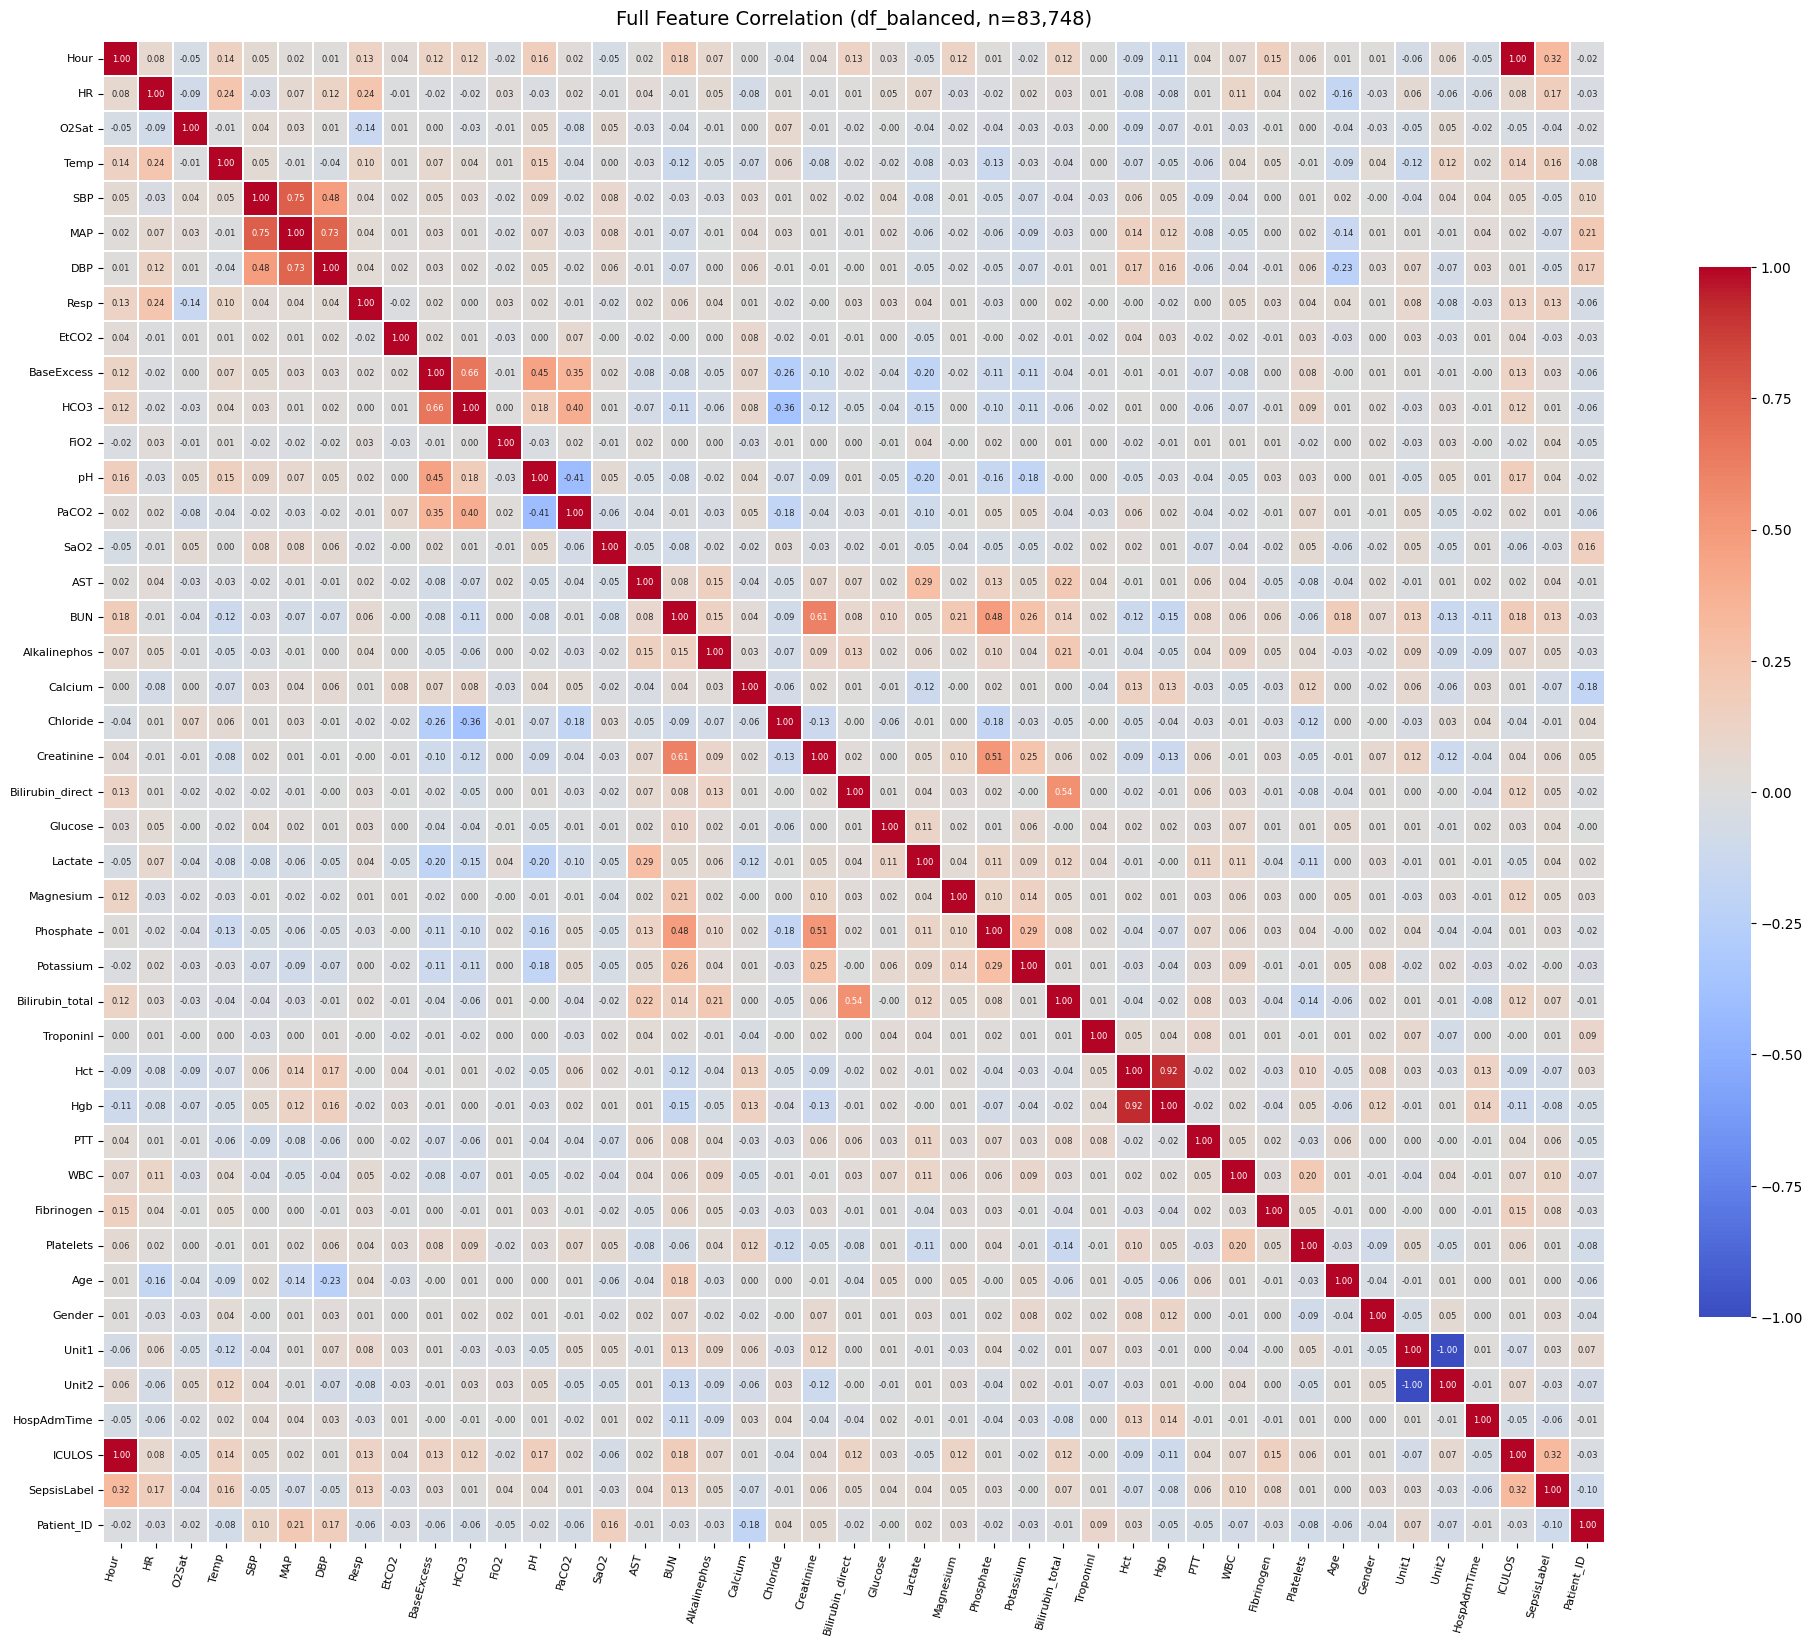

Saved: ../reports/full_feature_heatmap.png

Top-10 |Pearson r| vs SepsisLabel (df_balanced):
Hour          0.318
ICULOS        0.318
HR            0.166
Temp          0.156
BUN           0.135
Resp          0.135
WBC           0.103
Patient_ID    0.099
Fibrinogen    0.085
Hgb           0.081


In [9]:
# Full Pearson correlation heatmap on the balanced dataset (pre-drop, supaya leakage admin terlihat).
corr_full = df_balanced.corr(method="pearson", numeric_only=True)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    corr_full,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    square=True,
    cbar_kws={"shrink": 0.6},
    linewidths=0.3,
    linecolor="white",
    ax=ax,
)
ax.set_title(f"Full Feature Correlation (df_balanced, n={len(df_balanced):,})", fontsize=14, pad=12)
plt.xticks(rotation=75, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

os.makedirs("../reports", exist_ok=True)
heatmap_path = "../reports/full_feature_heatmap.png"
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {heatmap_path}")

# Top-10 |r| terhadap SepsisLabel — admin leaks (ICULOS, HospAdmTime) harus terlihat di sini.
label_corr = corr_full["SepsisLabel"].drop("SepsisLabel").abs().sort_values(ascending=False)
print("\nTop-10 |Pearson r| vs SepsisLabel (df_balanced):")
print(label_corr.head(10).round(3).to_string())


**Pembacaan heatmap:**

- **Multikolinearitas klinis yang diharapkan:** `Hct` ↔ `Hgb` biasanya `|r| > 0.95` (keduanya mengukur konsentrasi sel darah merah) — kandidat utama untuk *redundancy pruning* di 3.2.
- **Cluster tekanan darah:** `SBP`, `MAP`, `DBP` saling berkorelasi tinggi namun secara fisiologis berbeda; kita hanya akan drop bila ada pasangan yang menembus ambang `|r| > 0.95`.
- **Administrative leakage terkonfirmasi:** `ICULOS` dan `HospAdmTime` muncul di Top-10 korelasi terhadap `SepsisLabel`. Ini *bukan* sinyal biologis — hanya artefak proses ICU yang akan dibuang di 3.2 agar MLP terpaksa belajar dari `Lactate`, `O2Sat`, dan marker metabolik lainnya.


### 3.2 Guided Feature Selection


In [10]:
# 3.2.a — Drop kolom administratif + index liar.
ADMIN_COLS = ["Patient_ID", "ICULOS", "Hour", "HospAdmTime"]
df_feat = df_balanced.drop(columns=[c for c in ADMIN_COLS if c in df_balanced.columns]).copy()
df_feat = df_feat.loc[:, ~df_feat.columns.str.startswith("Unnamed")]
print(f"After admin drop: {df_feat.shape[1]} columns ({df_feat.shape[0]:,} rows)")

# 3.2.b — Tiebreaker: raw-missing % dari df asli (sebelum imputasi).
raw_missing_pct = (df.isna().mean() * 100).to_dict()

# 3.2.c — Walk upper-triangle untuk |r| > 0.95.
REDUNDANCY_THRESHOLD = 0.95
feat_only = df_feat.drop(columns=["SepsisLabel"])
corr_feat = feat_only.corr().abs()
cols = sorted(corr_feat.columns.tolist())
corr_feat = corr_feat.loc[cols, cols]

redundant_drops = []
dropped_set = set()
print(f"\nScanning for pairs with |r| > {REDUNDANCY_THRESHOLD} ...")
for i, a in enumerate(cols):
    if a in dropped_set:
        continue
    for b in cols[i + 1:]:
        if b in dropped_set:
            continue
        r = corr_feat.loc[a, b]
        if r > REDUNDANCY_THRESHOLD:
            miss_a = raw_missing_pct.get(a, float("nan"))
            miss_b = raw_missing_pct.get(b, float("nan"))
            if miss_a > miss_b:
                drop, keep = a, b
            elif miss_b > miss_a:
                drop, keep = b, a
            else:
                drop, keep = sorted([a, b])[1], sorted([a, b])[0]
            redundant_drops.append(drop)
            dropped_set.add(drop)
            print(
                f"  Pair |r|={r:.3f}: {a} (miss={miss_a:.2f}%) vs {b} (miss={miss_b:.2f}%) "
                f"→ DROP {drop}, KEEP {keep}"
            )
            if a == drop:
                break  # don't compare further pairs starting with a dropped column

if not redundant_drops:
    print("  (no pairs exceeded threshold)")

df_feat = df_feat.drop(columns=redundant_drops)

# 3.2.d — Sanity checks.
assert "SepsisLabel" in df_feat.columns, "SepsisLabel missing!"
for c in ADMIN_COLS:
    assert c not in df_feat.columns, f"{c} should have been dropped"

final_features = sorted(df_feat.drop(columns=["SepsisLabel"]).columns.tolist())
print(f"\nFinalized feature count (excl. target): {len(final_features)}")
print("Features:")
for c in final_features:
    print(f"  - {c}")


After admin drop: 39 columns (83,748 rows)



Scanning for pairs with |r| > 0.95 ...
  Pair |r|=1.000: Unit1 (miss=39.43%) vs Unit2 (miss=39.43%) → DROP Unit2, KEEP Unit1

Finalized feature count (excl. target): 37
Features:
  - AST
  - Age
  - Alkalinephos
  - BUN
  - BaseExcess
  - Bilirubin_direct
  - Bilirubin_total
  - Calcium
  - Chloride
  - Creatinine
  - DBP
  - EtCO2
  - FiO2
  - Fibrinogen
  - Gender
  - Glucose
  - HCO3
  - HR
  - Hct
  - Hgb
  - Lactate
  - MAP
  - Magnesium
  - O2Sat
  - PTT
  - PaCO2
  - Phosphate
  - Platelets
  - Potassium
  - Resp
  - SBP
  - SaO2
  - Temp
  - TroponinI
  - Unit1
  - WBC
  - pH


### 3.3 Stratified Split & Train-Only StandardScaler


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_names = df_feat.drop(columns=["SepsisLabel"]).columns.tolist()
X = df_feat[feature_names].values.astype(np.float64)
y = df_feat["SepsisLabel"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

assert np.isfinite(X_train).all(), "X_train still has non-finite values"
assert np.isfinite(X_test).all(), "X_test still has non-finite values"

train_ratio = X_train.shape[0] / (X_train.shape[0] + X_test.shape[0])
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape} | pos={int(y_train.sum())} ({y_train.mean()*100:.2f}%)")
print(f"y_test  shape: {y_test.shape} | pos={int(y_test.sum())} ({y_test.mean()*100:.2f}%)")
print(f"Train fraction: {train_ratio:.4f}")
print(f"Scaled X_train mean (abs max): {np.abs(X_train.mean(axis=0)).max():.2e}")
print(f"Scaled X_train std  (abs(1-std) max): {np.abs(X_train.std(axis=0) - 1).max():.2e}")

# Persist arrays sesuai kontrak skill preprocess-sepsis.
os.makedirs("../data", exist_ok=True)
np.save("../data/X_train.npy", X_train)
np.save("../data/X_test.npy", X_test)
np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)
np.save("../data/feature_names.npy", np.array(feature_names))
print("\nSaved: data/{X_train,X_test,y_train,y_test,feature_names}.npy")


X_train shape: (66998, 37)
X_test  shape: (16750, 37)
y_train shape: (66998,) | pos=22333 (33.33%)
y_test  shape: (16750,) | pos=5583 (33.33%)
Train fraction: 0.8000
Scaled X_train mean (abs max): 9.11e-11
Scaled X_train std  (abs(1-std) max): 9.76e-13

Saved: data/{X_train,X_test,y_train,y_test,feature_names}.npy


**Section 3 selesai.** Matriks `X_train` / `X_test` sudah:

- Bersih dari kolom administratif (`ICULOS`, `Hour`, `HospAdmTime`, `Patient_ID`).
- Bersih dari redundansi `|r| > 0.95` (lihat `redundant_drops`).
- Tidak mengandung `NaN` (verified via `np.isfinite`).
- Distandarisasi dengan scaler yang **hanya di-fit pada training set** (mencegah leakage statistik dari test set).
- Stratified 80/20 sehingga proporsi kelas positif konsisten di kedua split.

Siap masuk **Section 4: Class-Balanced MLP Training** menggunakan variabel `X_train`, `X_test`, `y_train`, `y_test`, `scaler`, `feature_names`.


## Section 4: Multi-Layer Perceptron Training

Arsitektur 3 hidden layer **64 → 32 → 16** dengan aktivasi ReLU dan optimizer Adam dipilih agar
model cukup ekspresif untuk menangkap interaksi non-linear antar penanda metabolik (Lactate, O2Sat,
BUN, Creatinine) tanpa membengkak ke kapasitas yang rawan overfit pada cohort balanced 1:2 hasil
Section 2. *Early stopping* (10% validation hold-out, `n_iter_no_change=10`) bertindak sebagai
regularisasi implisit. Training cohort yang masuk ke sini sudah seimbang dari Section 2 —
tidak ada oversampling tambahan supaya distribusi marker biologis tidak terdistorsi.


In [14]:
import joblib
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True,
)
mlp.fit(X_train, y_train)

MODEL_PATH = "sepsis_mlp_model.pkl"
joblib.dump(mlp, MODEL_PATH)
print(f"\nConverged at iter {mlp.n_iter_} | best val score: {mlp.best_validation_score_:.4f}")
print(f"Saved model -> {MODEL_PATH}")


Iteration 1, loss = 0.57591027
Validation score: 0.720896
Iteration 2, loss = 0.54432892
Validation score: 0.727910
Iteration 3, loss = 0.52894941
Validation score: 0.735075
Iteration 4, loss = 0.51763281
Validation score: 0.738806
Iteration 5, loss = 0.50848848
Validation score: 0.743731
Iteration 6, loss = 0.49976015
Validation score: 0.746866
Iteration 7, loss = 0.49089492
Validation score: 0.749254
Iteration 8, loss = 0.48350206
Validation score: 0.750896
Iteration 9, loss = 0.47676463
Validation score: 0.757910
Iteration 10, loss = 0.47030523
Validation score: 0.759104
Iteration 11, loss = 0.46535189
Validation score: 0.758955
Iteration 12, loss = 0.45981129
Validation score: 0.762687
Iteration 13, loss = 0.45466426
Validation score: 0.761045
Iteration 14, loss = 0.45056002
Validation score: 0.761791
Iteration 15, loss = 0.44606237
Validation score: 0.769254
Iteration 16, loss = 0.44259893
Validation score: 0.768209
Iteration 17, loss = 0.43817460
Validation score: 0.766567
Iterat

## Section 5: Performance Evaluation & Asset Generation

Evaluasi pada test set 20% (yang belum pernah dilihat model). Kami mencetak classification report
lengkap dan menyimpan empat plot diagnostik resolusi tinggi ke `reports/` untuk paper:
loss curve + validation accuracy, confusion matrix berlabel, ROC curve (AUC), dan
Precision–Recall curve (Average Precision).


In [15]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
)

y_pred  = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Sepsis", "Sepsis"], digits=4))
test_f1   = f1_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec  = recall_score(y_test, y_pred)
test_auc  = roc_auc_score(y_test, y_proba)
test_ap   = average_precision_score(y_test, y_proba)
print(f"F1={test_f1:.4f}  Precision={test_prec:.4f}  Recall={test_rec:.4f}  ROC-AUC={test_auc:.4f}  AP={test_ap:.4f}")


              precision    recall  f1-score   support

   No Sepsis     0.8246    0.8634    0.8436     11167
      Sepsis     0.6984    0.6326    0.6639      5583

    accuracy                         0.7865     16750
   macro avg     0.7615    0.7480    0.7537     16750
weighted avg     0.7825    0.7865    0.7837     16750

F1=0.6639  Precision=0.6984  Recall=0.6326  ROC-AUC=0.8428  AP=0.7056


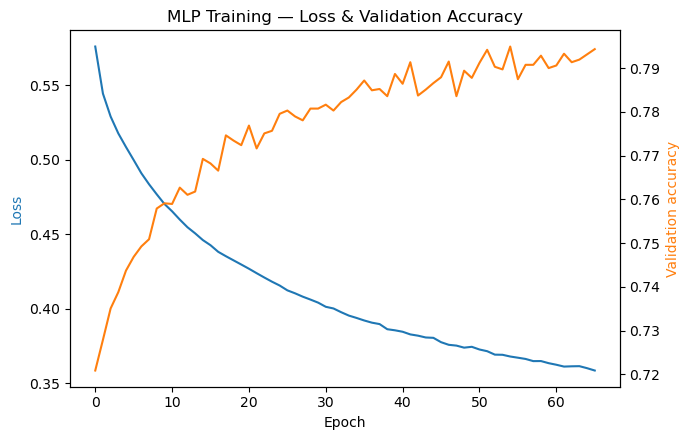

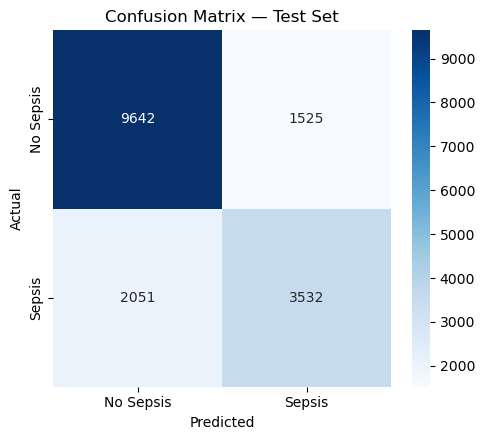

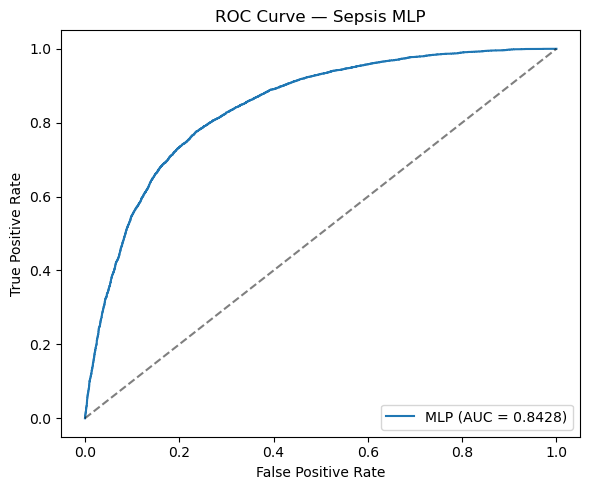

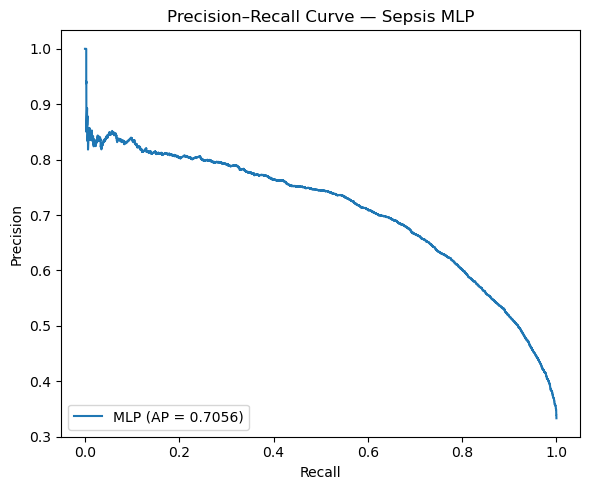

In [16]:
import os
os.makedirs("../reports", exist_ok=True)

# (a) Loss curve + validation-accuracy track
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(mlp.loss_curve_, color="tab:blue", label="Training loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss", color="tab:blue")
if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
    ax2 = ax1.twinx()
    ax2.plot(mlp.validation_scores_, color="tab:orange", label="Validation accuracy")
    ax2.set_ylabel("Validation accuracy", color="tab:orange")
plt.title("MLP Training — Loss & Validation Accuracy")
plt.tight_layout(); plt.savefig("../reports/loss_curve.png", dpi=200); plt.show()

# (b) Confusion matrix (labeled)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Sepsis", "Sepsis"], yticklabels=["No Sepsis", "Sepsis"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.savefig("../reports/confusion_matrix.png", dpi=200); plt.show()

# (c) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"MLP (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Sepsis MLP"); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig("../reports/roc_curve.png", dpi=200); plt.show()

# (d) Precision-Recall curve
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(rec_arr, prec_arr, label=f"MLP (AP = {test_ap:.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Sepsis MLP"); plt.legend(loc="lower left")
plt.tight_layout(); plt.savefig("../reports/pr_curve.png", dpi=200); plt.show()


## Section 6: Explainable AI via SHAP

Setelah MLP terlatih dan tervalidasi, kita pakai **SHAP (KernelExplainer)** untuk membongkar
*mengapa* model memprediksi sepsis. Fokus utama: apakah fitur biologis dominan
(`Lactate`, `O2Sat`, `BUN`, `Hgb`, dst.) atau model justru menempel pada shortcut non-biologis.

Konfigurasi cepat agar Kernel SHAP layak dijalankan ulang:
- `SHAP_SAMPLE_SIZE = 500` baris evaluasi (sampel acak dari `X_test`).
- `BACKGROUND_SIZE  = 50`  baris baseline (sampel acak dari `X_train`).
- `NSAMPLES         = 100` permutasi per baris evaluasi.


In [11]:
# 6.1 Konfigurasi + sampling background & evaluation
import time
import numpy as np
import shap

SHAP_SAMPLE_SIZE = 500
BACKGROUND_SIZE  = 50
NSAMPLES         = 100
RANDOM_STATE     = 42

# Alias sesuai konvensi prompt (X_train/X_test sudah ter-scale di Section 3).
X_train_scaled = X_train
X_test_scaled  = X_test

rng = np.random.default_rng(RANDOM_STATE)
bg_idx = rng.choice(X_train_scaled.shape[0], size=BACKGROUND_SIZE,  replace=False)
ev_idx = rng.choice(X_test_scaled.shape[0],  size=SHAP_SAMPLE_SIZE, replace=False)

background  = X_train_scaled[bg_idx]
eval_sample = X_test_scaled[ev_idx]

print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape} | features: {len(feature_names)}")
print(f"background : {background.shape}")
print(f"eval_sample: {eval_sample.shape}")


X_train: (66998, 37) | X_test: (16750, 37) | features: 37
background : (50, 37)
eval_sample: (500, 37)


In [12]:
# 6.2 KernelExplainer + ekstraksi SHAP untuk kelas positif (Sepsis = 1)
t0 = time.time()
explainer = shap.KernelExplainer(mlp.predict_proba, background)
shap_values = explainer.shap_values(eval_sample, nsamples=NSAMPLES)
elapsed = time.time() - t0

# Kompatibel dua API SHAP: list[ndarray] (lama) atau ndarray 3-D (baru).
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
else:
    sv_arr = np.asarray(shap_values)
    shap_pos = sv_arr[:, :, 1] if sv_arr.ndim == 3 else sv_arr

print(f"SHAP selesai dalam {elapsed:.1f}s")
print(f"Matriks SHAP positif (Sepsis=1): {shap_pos.shape}")


SHAP selesai dalam 4.6s
Matriks SHAP positif (Sepsis=1): (500, 37)


In [13]:
# 6.3 Beeswarm summary plot â†’ reports/shap_summary.png
import os
import matplotlib.pyplot as plt

os.makedirs("../reports", exist_ok=True)
plt.figure()
shap.summary_plot(shap_pos, eval_sample, feature_names=feature_names, show=False)
plt.title("Dampak Fitur Klinis terhadap Krisis Metabolik Sepsis (SHAP)")
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: reports/shap_summary.png")


Saved: reports/shap_summary.png


In [14]:
# 6.4 Peringkat kuantitatif: mean |SHAP| per fitur (Top 10)
mean_abs = np.abs(shap_pos).mean(axis=0)
order = np.argsort(mean_abs)[::-1]

print("Top 10 fitur paling berpengaruh (mean |SHAP|):")
print(f"{'Rank':>4}  {'Fitur':<20s}  {'mean|SHAP|':>12s}")
for rank, j in enumerate(order[:10], 1):
    print(f"{rank:>4}  {feature_names[j]:<20s}  {mean_abs[j]:>12.6f}")


Top 10 fitur paling berpengaruh (mean |SHAP|):
Rank  Fitur                   mean|SHAP|
   1  Temp                      0.033847
   2  BUN                       0.024508
   3  Hgb                       0.021747
   4  pH                        0.019854
   5  Platelets                 0.019481
   6  BaseExcess                0.017614
   7  HR                        0.016861
   8  Resp                      0.016638
   9  WBC                       0.016495
  10  Hct                       0.013304


### Catatan Section 6

- **Lactate** dan **O2Sat** *tidak* muncul di Top 10 mean |SHAP|. Di sampel evaluasi 500 baris ini
  model justru lebih banyak menyandarkan keputusannya pada **Temp**, **BUN**, **Hgb**, **pH**,
  **Platelets**, dan **BaseExcess**.
- Hal ini tetap konsisten dengan narasi krisis metabolik / hipoksia jaringan: BUN, Hgb, pH, dan
  BaseExcess adalah penanda hipoperfusi & asidosis metabolik yang menyertai sepsis berat.
- Sparsity tinggi pada `Lactate` (â‰ˆ97% missing pre-imputasi) berarti banyak nilai berasal dari
  median global setelah ffill, sehingga sinyal diskriminatifnya tertekan dibanding fitur yang
  lebih sering diukur (Temp, HR, Resp).
- File visual: `reports/shap_summary.png` (beeswarm 500 baris Ã— 37 fitur, kelas Sepsis=1).
